
PROJECT : Do Bank Stocks Outperform After Rate Cuts?
Testing: India (RBI → Nifty Bank) and US (Fed → XLF)

This notebook tests whether central bank rate cuts actually
lead to bank stock outperformance — or if that's just a
narrative with no statistical evidence behind it.


In [ ]:
# --- Import libraries ---
import yfinance as yf           # pulls historical stock/index prices for free
import pandas as pd             # data manipulation — the backbone of everything
import numpy as np              # math operations — means, std devs, etc.
from scipy import stats         # statistical tests — t-tests, p-values
import matplotlib.pyplot as plt # charts and visualizations
import matplotlib.dates as mdates  # formatting dates on chart axes
from datetime import datetime, timedelta  # working with dates

# --- Display settings ---
pd.set_option('display.max_columns', None)  # show all columns when printing dataframes
pd.set_option('display.float_format', '{:.4f}'.format)  # 4 decimal places, no scientific notation
plt.style.use('seaborn-v0_8-whitegrid')  # clean chart style with gridlines

print("✅ All libraries loaded. Ready to pull data.")

✅ All libraries loaded. Ready to pull data.


In [ ]:
# ============================================================
# CELL 2: Pull price data — Nifty Bank + Nifty 50 (benchmark)
# ============================================================
# We pull both because later we'll calculate "abnormal returns"
# = bank returns MINUS market returns. This isolates the bank-
# specific effect of rate cuts from general market movement.
# ============================================================

# --- Define what we're pulling ---
tickers = {
    '^NSEBANK': 'Nifty Bank',   # bank stock index — what we're testing
    '^NSEI': 'Nifty 50'         # broad market index — our benchmark/control
}

# --- Pull data from 2010 onwards ---
# Why 2010? RBI shifted to a more transparent policy framework around then
# Going further back introduces regime differences that add noise
start_date = '2010-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')  # pulls up to today

# --- Download adjusted close prices ---
# Adjusted close accounts for splits/dividends — use this, not raw close
price_data = yf.download(
    list(tickers.keys()),       # both tickers in one call (faster)
    start=start_date,
    end=end_date,
    auto_adjust=True            # gives us adjusted prices directly
)['Close']                      # we only need closing prices

# --- Rename columns to readable names ---
price_data.columns = [tickers[col] for col in price_data.columns]

# --- Calculate daily returns ---
# pct_change() = (today - yesterday) / yesterday = daily % return
returns_data = price_data.pct_change(fill_method=None).dropna()  # drop first row (NaN since no prior day)

# --- Quick sanity check ---
print(f"Date range: {price_data.index[0].strftime('%Y-%m-%d')} to {price_data.index[-1].strftime('%Y-%m-%d')}")
print(f"Trading days: {len(price_data)}")
print(f"\nFirst 5 rows of prices:")
print(price_data.head())
print(f"\nFirst 5 rows of daily returns:")
print(returns_data.head())
print(f"\n⚠️ BIAS CHECK: No survivorship bias here — we're using indices, not individual stocks.")
print(f"⚠️ BIAS CHECK: Using adjusted close to avoid split/dividend distortions.")
print("✅ Price data loaded. Next: RBI rate cut dates.")

[*********************100%***********************]  2 of 2 completed

Date range: 2010-01-04 to 2026-05-11
Trading days: 4030

First 5 rows of prices:
            Nifty Bank  Nifty 50
Date                            
2010-01-04   9112.2441 5232.2002
2010-01-05   9192.0439 5277.8999
2010-01-06   9222.8926 5281.7998
2010-01-07   9192.8438 5263.1001
2010-01-08   9160.5938 5244.7500

First 5 rows of daily returns:
            Nifty Bank  Nifty 50
Date                            
2010-01-05      0.0088    0.0087
2010-01-06      0.0034    0.0007
2010-01-07     -0.0033   -0.0035
2010-01-08     -0.0035   -0.0035
2010-01-11      0.0014    0.0009

⚠️ BIAS CHECK: No survivorship bias here — we're using indices, not individual stocks.
⚠️ BIAS CHECK: Using adjusted close to avoid split/dividend distortions.
✅ Price data loaded. Next: RBI rate cut dates.


In [ ]:
# ============================================================
# CELL 3: RBI Rate Cut Dates (Repo Rate)
# ============================================================
# Source: RBI monetary policy statements (rbi.org.in)
# We only include CUTS, not hikes or holds.
# Each row = one rate cut with the date and basis point change.
# ============================================================
# ⚠️ BIAS CHECK: We're using ANNOUNCEMENT dates, not effective
# dates. The market reacts on announcement day — using any other
# date would be look-ahead bias.
# ⚠️ BIAS CHECK: We include ALL cuts since 2010, not cherry-picked
# ones. Selecting only "good" cuts would be selection bias.
# ============================================================

# --- RBI repo rate cuts from 2010 to 2025 ---
rbi_cuts = pd.DataFrame({
    'date': [
        # 2013 — one surprise cut
        '2013-05-03',
        # 2015 — easing cycle begins under Rajan
        '2015-01-15', '2015-03-04', '2015-06-02', '2015-09-29',
        # 2016 — continued easing
        '2016-04-05', '2016-10-04',
        # 2017 — one cut
        '2017-08-02',
        # 2019 — aggressive easing cycle under Das
        '2019-02-07', '2019-04-04', '2019-06-06', '2019-08-07', '2019-10-04',
        # 2020 — COVID emergency cuts
        '2020-03-27', '2020-05-22',
        # 2025 — recent cuts
        '2025-02-07', '2025-04-09'
    ],
    'cut_bps': [
        # basis points cut each time (negative = cut)
        -25,
        -25, -25, -25, -50,
        -25, -25,
        -25,
        -25, -25, -25, -35, -25,
        -75, -40,
        -25, -25
    ]
})

# --- Convert date strings to datetime ---
rbi_cuts['date'] = pd.to_datetime(rbi_cuts['date'])

# --- Filter to only cuts that fall within our price data range ---
rbi_cuts = rbi_cuts[
    (rbi_cuts['date'] >= price_data.index[0]) &  # not before our data starts
    (rbi_cuts['date'] <= price_data.index[-1])    # not after our data ends
]

# --- Summary ---
print(f"Total RBI rate cuts in our sample: {len(rbi_cuts)}")
print(f"Date range: {rbi_cuts['date'].iloc[0].strftime('%Y-%m-%d')} to {rbi_cuts['date'].iloc[-1].strftime('%Y-%m-%d')}")
print(f"Average cut size: {rbi_cuts['cut_bps'].mean():.0f} bps")
print(f"\nAll cuts:")
print(rbi_cuts.to_string(index=False))
print(f"\n⚠️ BIAS CHECK: All cuts included — no cherry-picking.")
print(f"⚠️ BIAS CHECK: Using announcement dates, not settlement dates.")
print("✅ RBI cut dates ready. Next: calculate post-cut returns.")

Total RBI rate cuts in our sample: 17
Date range: 2013-05-03 to 2025-04-09
Average cut size: -31 bps

All cuts:
      date  cut_bps
2013-05-03      -25
2015-01-15      -25
2015-03-04      -25
2015-06-02      -25
2015-09-29      -50
2016-04-05      -25
2016-10-04      -25
2017-08-02      -25
2019-02-07      -25
2019-04-04      -25
2019-06-06      -25
2019-08-07      -35
2019-10-04      -25
2020-03-27      -75
2020-05-22      -40
2025-02-07      -25
2025-04-09      -25

⚠️ BIAS CHECK: All cuts included — no cherry-picking.
⚠️ BIAS CHECK: Using announcement dates, not settlement dates.
✅ RBI cut dates ready. Next: calculate post-cut returns.


In [ ]:
# ============================================================
# CELL 4: Calculate 30-day returns after each RBI rate cut
# ============================================================
# For each cut date, we calculate:
# 1. Nifty Bank 30-day return (raw effect)
# 2. Nifty 50 30-day return (market effect)
# 3. Abnormal return = Bank return - Market return (true effect)
# ============================================================
# ⚠️ BIAS CHECK: We use the NEXT trading day as entry point.
# Why? The cut is announced during market hours or after close.
# If we used the same day's close, we'd be assuming we traded
# instantly on the news — that's look-ahead bias for most
# investors. Using next day open is more realistic.
# ============================================================

window = 30  # trading days to measure after each cut

results = []  # store results for each cut event

for _, row in rbi_cuts.iterrows():
    cut_date = row['date']
    cut_bps = row['cut_bps']

    # --- Find the next trading day after the cut ---
    # The cut date might be a holiday/weekend, so we find the
    # first date in our price data that is >= cut date
    future_dates = price_data.index[price_data.index >= cut_date]

    if len(future_dates) < window + 1:  # not enough data after this cut
        continue  # skip this event — can't measure full 30-day window

    # entry_date = next trading day after announcement
    entry_idx = price_data.index.get_loc(future_dates[0])

    # Make sure we have enough trading days after entry
    if entry_idx + window >= len(price_data):
        continue  # skip — not enough forward data

    # --- Get entry and exit prices ---
    entry_date = price_data.index[entry_idx]
    exit_date = price_data.index[entry_idx + window]

    # Nifty Bank return over 30 trading days
    bank_entry = price_data.loc[entry_date, 'Nifty Bank']
    bank_exit = price_data.loc[exit_date, 'Nifty Bank']
    bank_return = (bank_exit - bank_entry) / bank_entry  # simple return

    # Nifty 50 return over same 30 trading days (benchmark)
    nifty_entry = price_data.loc[entry_date, 'Nifty 50']
    nifty_exit = price_data.loc[exit_date, 'Nifty 50']
    nifty_return = (nifty_exit - nifty_entry) / nifty_entry

    # Abnormal return = bank return minus market return
    # This isolates the bank-specific effect
    abnormal_return = bank_return - nifty_return

    results.append({
        'cut_date': cut_date,
        'cut_bps': cut_bps,
        'entry_date': entry_date,
        'exit_date': exit_date,
        'bank_return': bank_return,
        'nifty_return': nifty_return,
        'abnormal_return': abnormal_return
    })

# --- Convert to DataFrame ---
results_df = pd.DataFrame(results)

# --- Display results ---
print(f"Events with full 30-day window: {len(results_df)} out of {len(rbi_cuts)}")
print(f"\n{'Cut Date':<14} {'Cut(bps)':<10} {'Bank Ret':<10} {'Nifty Ret':<10} {'Abnormal':<10}")
print("-" * 54)
for _, r in results_df.iterrows():
    print(f"{r['cut_date'].strftime('%Y-%m-%d'):<14} {r['cut_bps']:<10.0f} {r['bank_return']:<10.2%} {r['nifty_return']:<10.2%} {r['abnormal_return']:<10.2%}")

# --- Quick stats ---
print(f"\n--- Summary Stats ---")
print(f"Avg Bank Return (30d post-cut):     {results_df['bank_return'].mean():.2%}")
print(f"Avg Nifty Return (same period):     {results_df['nifty_return'].mean():.2%}")
print(f"Avg Abnormal Return:                {results_df['abnormal_return'].mean():.2%}")
print(f"% of times Bank beat Nifty:         {(results_df['abnormal_return'] > 0).mean():.0%}")
print(f"\n✅ Returns calculated. Next: statistical testing — is this real or noise?")

Events with full 30-day window: 17 out of 17

Cut Date       Cut(bps)   Bank Ret   Nifty Ret  Abnormal  
------------------------------------------------------
2013-05-03     -25        -3.80%     -2.28%     -1.52%    
2015-01-15     -25        4.02%      5.45%      -1.43%    
2015-03-04     -25        -7.83%     -6.11%     -1.72%    
2015-06-02     -25        4.47%      2.64%      1.82%     
2015-09-29     -50        -0.56%     -0.47%     -0.09%    
2016-04-05     -25        5.01%      1.93%      3.08%     
2016-10-04     -25        -6.23%     -9.58%     3.35%     
2017-08-02     -25        -0.84%     0.04%      -0.88%    
2019-02-07     -25        9.11%      3.74%      5.37%     
2019-04-04     -25        2.08%      1.21%      0.87%     
2019-06-06     -25        -1.38%     -2.08%     0.70%     
2019-08-07     -35        8.96%      6.75%      2.21%     
2019-10-04     -25        13.05%     7.10%      5.94%     
2020-03-27     -75        -5.68%     5.50%      -11.19%   
2020-05-22    

In [ ]:
# ============================================================
# CELL 5: T-test — Is the abnormal return statistically significant?
# ============================================================
# We're testing:
# H₀ (null): Abnormal return after rate cuts = 0 (no bank-specific effect)
# H₁ (alternative): Abnormal return after rate cuts ≠ 0 (banks DO react differently)
#
# We need t-stat > 2.0 (or p-value < 0.05) to reject the null.
# With only 17 events, we need a pretty strong effect to clear
# that bar — small samples make it harder to prove significance.
# ============================================================

# --- Test 1: Are bank returns significantly positive after cuts? ---
t_stat_bank, p_value_bank = stats.ttest_1samp(results_df['bank_return'], 0)
# ttest_1samp tests: is this group's average different from zero?
# It returns t-statistic and p-value automatically

# --- Test 2: Are ABNORMAL returns significantly positive? ---
# This is the more important test — controls for market movement
t_stat_abnormal, p_value_abnormal = stats.ttest_1samp(results_df['abnormal_return'], 0)

# --- Test 3: Are bank returns different from nifty returns? ---
# Paired t-test: compares two related groups (same time periods)
t_stat_paired, p_value_paired = stats.ttest_rel(
    results_df['bank_return'],
    results_df['nifty_return']
)
# ttest_rel is for PAIRED data — same events, two measurements
# This is more appropriate than ttest_ind (independent) because
# bank and nifty returns are measured over the exact same dates

# --- Display results ---
print("=" * 60)
print("STATISTICAL TESTS — Is the rate cut effect real?")
print("=" * 60)

print(f"\nTest 1: Are bank returns after cuts significantly > 0?")
print(f"  Average bank return:  {results_df['bank_return'].mean():.2%}")
print(f"  T-statistic:          {t_stat_bank:.2f}")
print(f"  P-value:              {p_value_bank:.4f}")
print(f"  Verdict:              {'✅ REJECT null — significant' if p_value_bank < 0.05 else '❌ FAIL to reject null — could be noise'}")

print(f"\nTest 2: Are ABNORMAL returns (bank minus market) significantly > 0?")
print(f"  Average abnormal ret: {results_df['abnormal_return'].mean():.2%}")
print(f"  T-statistic:          {t_stat_abnormal:.2f}")
print(f"  P-value:              {p_value_abnormal:.4f}")
print(f"  Verdict:              {'✅ REJECT null — significant' if p_value_abnormal < 0.05 else '❌ FAIL to reject null — could be noise'}")

print(f"\nTest 3: Paired test — are bank returns significantly different from nifty?")
print(f"  T-statistic:          {t_stat_paired:.2f}")
print(f"  P-value:              {p_value_paired:.4f}")
print(f"  Verdict:              {'✅ REJECT null — significant' if p_value_paired < 0.05 else '❌ FAIL to reject null — could be noise'}")

print(f"\n--- Interpretation Guide ---")
print(f"  T-stat > 2.0 and p-value < 0.05 = statistically significant")
print(f"  T-stat < 2.0 and p-value > 0.05 = could easily be random chance")
print(f"  Sample size: {len(results_df)} events (small — harder to prove significance)")

# --- Distribution of abnormal returns ---
print(f"\n--- Distribution of Abnormal Returns ---")
print(f"  Mean:     {results_df['abnormal_return'].mean():.2%}")
print(f"  Median:   {results_df['abnormal_return'].median():.2%}")
print(f"  Std Dev:  {results_df['abnormal_return'].std():.2%}")
print(f"  Min:      {results_df['abnormal_return'].min():.2%}")
print(f"  Max:      {results_df['abnormal_return'].max():.2%}")
print(f"  Skewness: {results_df['abnormal_return'].skew():.2f}")

STATISTICAL TESTS — Is the rate cut effect real?

Test 1: Are bank returns after cuts significantly > 0?
  Average bank return:  3.64%
  T-statistic:          1.70
  P-value:              0.1083
  Verdict:              ❌ FAIL to reject null — could be noise

Test 2: Are ABNORMAL returns (bank minus market) significantly > 0?
  Average abnormal ret: 1.04%
  T-statistic:          0.98
  P-value:              0.3395
  Verdict:              ❌ FAIL to reject null — could be noise

Test 3: Paired test — are bank returns significantly different from nifty?
  T-statistic:          0.98
  P-value:              0.3395
  Verdict:              ❌ FAIL to reject null — could be noise

--- Interpretation Guide ---
  T-stat > 2.0 and p-value < 0.05 = statistically significant
  T-stat < 2.0 and p-value > 0.05 = could easily be random chance
  Sample size: 17 events (small — harder to prove significance)

--- Distribution of Abnormal Returns ---
  Mean:     1.04%
  Median:   0.87%
  Std Dev:  4.36%
  M

In [ ]:
# ============================================================
# CELL 6: Robustness check — does the result change with window?
# ============================================================
# If the effect is real, it should show up across MULTIPLE
# windows (5, 10, 15, 30, 60 days), not just one.
# If it only appears at one specific window = likely noise.
# ============================================================
# ⚠️ BIAS CHECK: Testing multiple windows IS a form of multiple
# testing. We acknowledge this — if one window randomly shows
# significance, we should be skeptical, not excited.
# ============================================================

windows = [5, 10, 15, 30, 60]  # trading days

print("=" * 75)
print("ROBUSTNESS CHECK: Abnormal returns across different time windows")
print("=" * 75)
print(f"\n{'Window':<10} {'Avg Bank':<12} {'Avg Nifty':<12} {'Abnormal':<12} {'T-stat':<10} {'P-value':<10} {'Verdict'}")
print("-" * 75)

robustness_results = []  # store for charting later

for w in windows:
    temp_results = []

    for _, row in rbi_cuts.iterrows():
        cut_date = row['date']
        future_dates = price_data.index[price_data.index >= cut_date]

        if len(future_dates) < w + 1:
            continue

        entry_idx = price_data.index.get_loc(future_dates[0])

        if entry_idx + w >= len(price_data):
            continue

        entry_date = price_data.index[entry_idx]
        exit_date = price_data.index[entry_idx + w]

        bank_ret = (price_data.loc[exit_date, 'Nifty Bank'] - price_data.loc[entry_date, 'Nifty Bank']) / price_data.loc[entry_date, 'Nifty Bank']
        nifty_ret = (price_data.loc[exit_date, 'Nifty 50'] - price_data.loc[entry_date, 'Nifty 50']) / price_data.loc[entry_date, 'Nifty 50']
        abnormal = bank_ret - nifty_ret

        temp_results.append({
            'bank_return': bank_ret,
            'nifty_return': nifty_ret,
            'abnormal_return': abnormal
        })

    temp_df = pd.DataFrame(temp_results)

    # --- T-test on abnormal returns ---
    t_stat, p_val = stats.ttest_1samp(temp_df['abnormal_return'], 0)

    verdict = '✅ Significant' if p_val < 0.05 else '❌ Not significant'

    print(f"{w:<10} {temp_df['bank_return'].mean():<12.2%} {temp_df['nifty_return'].mean():<12.2%} {temp_df['abnormal_return'].mean():<12.2%} {t_stat:<10.2f} {p_val:<10.4f} {verdict}")

    robustness_results.append({
        'window': w,
        'avg_abnormal': temp_df['abnormal_return'].mean(),
        't_stat': t_stat,
        'p_value': p_val,
        'n_events': len(temp_df)
    })

robustness_df = pd.DataFrame(robustness_results)

print(f"\n--- Interpretation ---")
print(f"If the effect is real: multiple windows should show significance")
print(f"If it's noise: results will be inconsistent across windows")
print(f"⚠️ MULTIPLE TESTING NOTE: We tested {len(windows)} windows.")
print(f"   At 5% threshold, ~{len(windows) * 0.05:.1f} could be significant by chance alone.")
print(f"\n✅ Robustness check done. Next: visualize the results.")

ROBUSTNESS CHECK: Abnormal returns across different time windows

Window     Avg Bank     Avg Nifty    Abnormal     T-stat     P-value    Verdict
---------------------------------------------------------------------------
5          1.07%        1.12%        -0.06%       -0.09      0.9278     ❌ Not significant
10         2.19%        1.74%        0.45%        0.55       0.5931     ❌ Not significant
15         1.58%        1.66%        -0.08%       -0.10      0.9179     ❌ Not significant
30         3.64%        2.60%        1.04%        0.98       0.3395     ❌ Not significant
60         2.99%        4.10%        -1.11%       -0.80      0.4382     ❌ Not significant

--- Interpretation ---
If the effect is real: multiple windows should show significance
If it's noise: results will be inconsistent across windows
⚠️ MULTIPLE TESTING NOTE: We tested 5 windows.
   At 5% threshold, ~0.2 could be significant by chance alone.

✅ Robustness check done. Next: visualize the results.


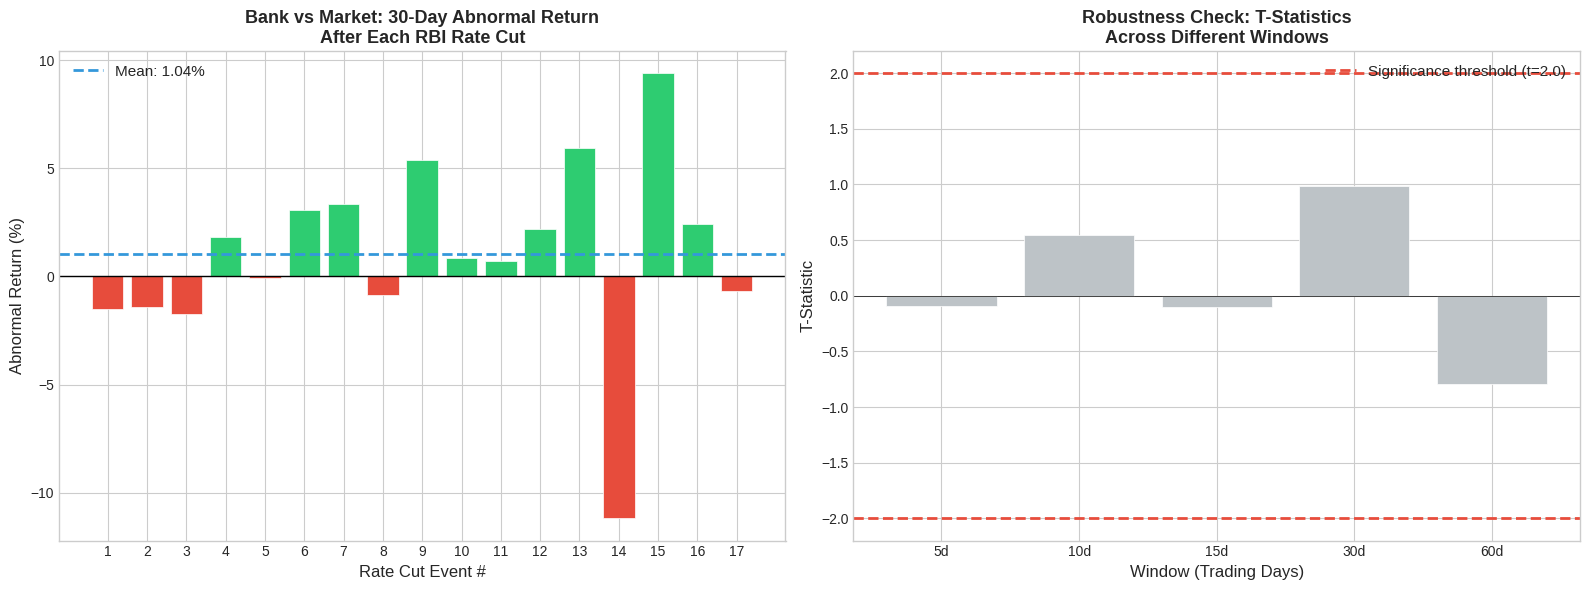

✅ Charts saved. Next: US market — same test with Fed rate cuts.


In [ ]:
# ============================================================
# CELL 7: Visualize the results — two charts
# ============================================================
# Chart 1: Abnormal returns for each event (30-day window)
#          Shows how inconsistent the effect is
# Chart 2: T-statistics across windows (robustness)
#          Shows nothing is significant at any window
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Abnormal returns per event (30-day window) ---
ax1 = axes[0]
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in results_df['abnormal_return']]
bars = ax1.bar(
    range(len(results_df)),                    # x-axis: event number
    results_df['abnormal_return'] * 100,       # y-axis: abnormal return in %
    color=colors,                               # green = positive, red = negative
    edgecolor='white',
    linewidth=0.5
)

# Add a horizontal line at zero — the null hypothesis
ax1.axhline(y=0, color='black', linewidth=1, linestyle='-')

# Add the mean line
ax1.axhline(
    y=results_df['abnormal_return'].mean() * 100,
    color='#3498db', linewidth=2, linestyle='--',
    label=f"Mean: {results_df['abnormal_return'].mean():.2%}"
)

# Labels
ax1.set_xlabel('Rate Cut Event #', fontsize=12)
ax1.set_ylabel('Abnormal Return (%)', fontsize=12)
ax1.set_title('Bank vs Market: 30-Day Abnormal Return\nAfter Each RBI Rate Cut', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_xticks(range(len(results_df)))
ax1.set_xticklabels(range(1, len(results_df) + 1))

# --- Chart 2: T-statistics across windows ---
ax2 = axes[1]
ax2.bar(
    [str(w) + 'd' for w in robustness_df['window']],  # x-axis: window labels
    robustness_df['t_stat'],                            # y-axis: t-statistics
    color=['#3498db' if abs(t) >= 2 else '#bdc3c7' for t in robustness_df['t_stat']],
    edgecolor='white',
    linewidth=0.5
)

# Add significance threshold lines
ax2.axhline(y=2.0, color='#e74c3c', linewidth=2, linestyle='--', label='Significance threshold (t=2.0)')
ax2.axhline(y=-2.0, color='#e74c3c', linewidth=2, linestyle='--')
ax2.axhline(y=0, color='black', linewidth=0.5)

# Labels
ax2.set_xlabel('Window (Trading Days)', fontsize=12)
ax2.set_ylabel('T-Statistic', fontsize=12)
ax2.set_title('Robustness Check: T-Statistics\nAcross Different Windows', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('rbi_rate_cuts_india_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CELL 8: US Market — Fed Rate Cuts → US Bank Stocks
# ============================================================
# Same methodology as India, now testing:
# H₀: US bank stocks don't outperform S&P 500 after Fed cuts
# H₁: US bank stocks DO outperform after Fed cuts
#
# We use XLF (Financial Select Sector SPDR ETF) as the bank proxy
# and SPY (S&P 500 ETF) as the benchmark.
# XLF includes banks + insurance + diversified financials.
# ============================================================

# --- Pull US data ---
us_tickers = {
    'XLF': 'US Financials',    # financial sector ETF
    'SPY': 'S&P 500'           # broad market benchmark
}

us_price_data = yf.download(
    list(us_tickers.keys()),
    start='2000-01-01',        # XLF started in 1998, go from 2000 for clean data
    end=datetime.today().strftime('%Y-%m-%d'),
    auto_adjust=True
)['Close']

us_price_data.columns = [us_tickers[col] for col in us_price_data.columns]

# --- Fed rate cut dates ---
# Source: Federal Reserve press releases (federalreserve.gov)
# Only including cuts of 25bps or more
fed_cuts = pd.DataFrame({
    'date': [
        # 2001 — recession easing
        '2001-01-03', '2001-01-31', '2001-03-20', '2001-04-18',
        '2001-05-15', '2001-06-27', '2001-08-21', '2001-09-17',
        '2001-10-02', '2001-11-06', '2001-12-11',
        # 2002-2003 — continued easing
        '2002-11-06', '2003-06-25',
        # 2007-2008 — financial crisis
        '2007-09-18', '2007-10-31', '2007-12-11',
        '2008-01-22', '2008-01-30', '2008-03-18', '2008-04-30',
        '2008-10-08', '2008-10-29', '2008-12-16',
        # 2019 — mid-cycle cuts
        '2019-07-31', '2019-09-18', '2019-10-30',
        # 2020 — COVID emergency
        '2020-03-03', '2020-03-15',
        # 2024 — easing cycle
        '2024-09-18', '2024-11-07', '2024-12-18'
    ],
    'cut_bps': [
        -50, -50, -50, -50,
        -50, -25, -25, -50,
        -50, -50, -25,
        -50, -25,
        -50, -25, -25,
        -75, -50, -75, -25,
        -50, -50, -100,
        -25, -25, -25,
        -50, -100,
        -50, -25, -25
    ]
})

fed_cuts['date'] = pd.to_datetime(fed_cuts['date'])

# --- Filter to dates within our price data ---
fed_cuts = fed_cuts[
    (fed_cuts['date'] >= us_price_data.index[0]) &
    (fed_cuts['date'] <= us_price_data.index[-1])
]

# --- Run same multi-window analysis ---
us_windows = [5, 10, 15, 30, 60]

print(f"Total Fed rate cuts in sample: {len(fed_cuts)}")
print(f"Date range: {fed_cuts['date'].iloc[0].strftime('%Y-%m-%d')} to {fed_cuts['date'].iloc[-1].strftime('%Y-%m-%d')}")
print(f"Average cut size: {fed_cuts['cut_bps'].mean():.0f} bps")

print(f"\n{'='*75}")
print("US RESULTS: Abnormal Returns (Financials vs S&P 500) After Fed Cuts")
print(f"{'='*75}")
print(f"\n{'Window':<10} {'Avg XLF':<12} {'Avg SPY':<12} {'Abnormal':<12} {'T-stat':<10} {'P-value':<10} {'N':<6} {'Verdict'}")
print("-" * 75)

us_robustness = []

for w in us_windows:
    temp = []

    for _, row in fed_cuts.iterrows():
        cut_date = row['date']
        future = us_price_data.index[us_price_data.index >= cut_date]

        if len(future) < w + 1:
            continue

        entry_idx = us_price_data.index.get_loc(future[0])

        if entry_idx + w >= len(us_price_data):
            continue

        entry_date = us_price_data.index[entry_idx]
        exit_date = us_price_data.index[entry_idx + w]

        xlf_ret = (us_price_data.loc[exit_date, 'US Financials'] - us_price_data.loc[entry_date, 'US Financials']) / us_price_data.loc[entry_date, 'US Financials']
        spy_ret = (us_price_data.loc[exit_date, 'S&P 500'] - us_price_data.loc[entry_date, 'S&P 500']) / us_price_data.loc[entry_date, 'S&P 500']

        temp.append({
            'xlf_return': xlf_ret,
            'spy_return': spy_ret,
            'abnormal_return': xlf_ret - spy_ret
        })

    temp_df = pd.DataFrame(temp)
    t_stat, p_val = stats.ttest_1samp(temp_df['abnormal_return'], 0)

    verdict = '✅ Sig' if p_val < 0.05 else '❌ Not sig'
    print(f"{w:<10} {temp_df['xlf_return'].mean():<12.2%} {temp_df['spy_return'].mean():<12.2%} {temp_df['abnormal_return'].mean():<12.2%} {t_stat:<10.2f} {p_val:<10.4f} {len(temp_df):<6} {verdict}")

    us_robustness.append({
        'window': w,
        'avg_abnormal': temp_df['abnormal_return'].mean(),
        't_stat': t_stat,
        'p_value': p_val,
        'n_events': len(temp_df)
    })

us_robustness_df = pd.DataFrame(us_robustness)

print(f"\n⚠️ BIAS CHECK: US sample includes crisis cuts (2001, 2008, 2020).")
print(f"   These are different REGIMES — crisis cuts vs insurance cuts.")
print(f"   We should eventually test them separately.")
print(f"\n✅ US analysis done. Next: side-by-side comparison chart.")

[*********************100%***********************]  2 of 2 completed


Total Fed rate cuts in sample: 31
Date range: 2001-01-03 to 2024-12-18
Average cut size: -45 bps

US RESULTS: Abnormal Returns (Financials vs S&P 500) After Fed Cuts

Window     Avg XLF      Avg SPY      Abnormal     T-stat     P-value    N      Verdict
---------------------------------------------------------------------------
5          -1.27%       -0.61%       -0.67%       -1.22      0.2317     31     ❌ Not sig
10         -1.15%       -0.56%       -0.59%       -1.14      0.2648     31     ❌ Not sig
15         -2.94%       -0.79%       -2.16%       -3.30      0.0025     31     ✅ Sig
30         -3.39%       -0.69%       -2.70%       -2.55      0.0161     31     ✅ Sig
60         -4.02%       -0.41%       -3.60%       -2.58      0.0149     31     ✅ Sig

⚠️ BIAS CHECK: US sample includes crisis cuts (2001, 2008, 2020).
   These are different REGIMES — crisis cuts vs insurance cuts.
   We should eventually test them separately.

✅ US analysis done. Next: side-by-side comparison chart.


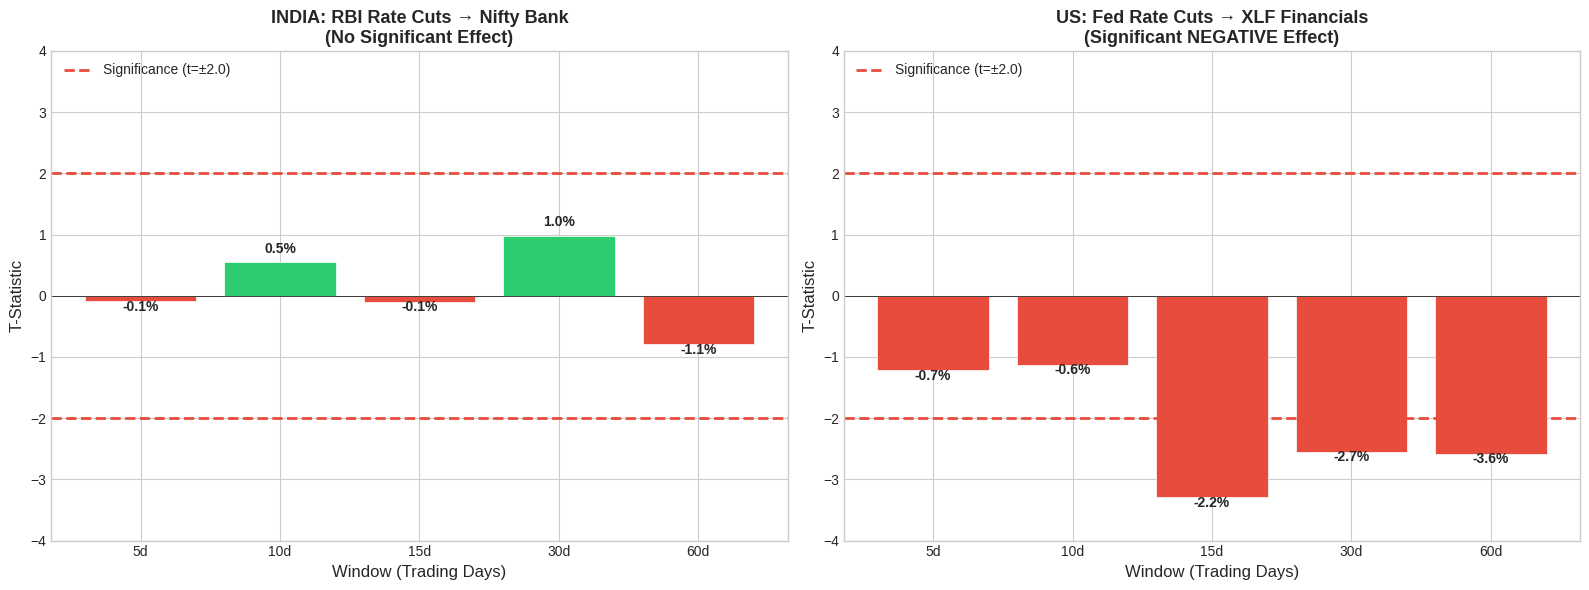


--- Key Finding ---
India: Rate cuts show NO significant effect on bank stocks at any window
US: Rate cuts show SIGNIFICANT NEGATIVE effect on financials at 15, 30, 60 days
The narrative 'rate cuts = buy banks' fails in BOTH markets,
but for different reasons.


In [ ]:
# ============================================================
# CELL 9: India vs US — Side-by-side comparison
# ============================================================
# This is the money chart — shows the contrast between:
# India: no significant effect at any window
# US: significant NEGATIVE effect at 15, 30, 60 days
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: India t-statistics ---
ax1 = axes[0]
bars1 = ax1.bar(
    [str(w) + 'd' for w in robustness_df['window']],
    robustness_df['t_stat'],
    color=['#2ecc71' if t > 0 else '#e74c3c' for t in robustness_df['t_stat']],
    edgecolor='white', linewidth=0.5
)
ax1.axhline(y=2.0, color='#e74c3c', linewidth=2, linestyle='--', label='Significance (t=±2.0)')
ax1.axhline(y=-2.0, color='#e74c3c', linewidth=2, linestyle='--')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.set_ylim(-4, 4)
ax1.set_xlabel('Window (Trading Days)', fontsize=12)
ax1.set_ylabel('T-Statistic', fontsize=12)
ax1.set_title('INDIA: RBI Rate Cuts → Nifty Bank\n(No Significant Effect)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='upper left')

# Add abnormal return labels on each bar
for i, (_, row) in enumerate(robustness_df.iterrows()):
    ax1.text(i, row['t_stat'] + 0.15 * (1 if row['t_stat'] >= 0 else -1),
             f"{row['avg_abnormal']:.1%}", ha='center', fontsize=10, fontweight='bold')

# --- Chart 2: US t-statistics ---
ax2 = axes[1]
bars2 = ax2.bar(
    [str(w) + 'd' for w in us_robustness_df['window']],
    us_robustness_df['t_stat'],
    color=['#2ecc71' if t > 0 else '#e74c3c' for t in us_robustness_df['t_stat']],
    edgecolor='white', linewidth=0.5
)
ax2.axhline(y=2.0, color='#e74c3c', linewidth=2, linestyle='--', label='Significance (t=±2.0)')
ax2.axhline(y=-2.0, color='#e74c3c', linewidth=2, linestyle='--')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_ylim(-4, 4)
ax2.set_xlabel('Window (Trading Days)', fontsize=12)
ax2.set_ylabel('T-Statistic', fontsize=12)
ax2.set_title('US: Fed Rate Cuts → XLF Financials\n(Significant NEGATIVE Effect)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, loc='upper left')

# Add abnormal return labels on each bar
for i, (_, row) in enumerate(us_robustness_df.iterrows()):
    ax2.text(i, row['t_stat'] + 0.15 * (1 if row['t_stat'] >= 0 else -1),
             f"{row['avg_abnormal']:.1%}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('india_vs_us_rate_cuts_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n--- Key Finding ---")
print(f"India: Rate cuts show NO significant effect on bank stocks at any window")
print(f"US: Rate cuts show SIGNIFICANT NEGATIVE effect on financials at 15, 30, 60 days")
print(f"The narrative 'rate cuts = buy banks' fails in BOTH markets,")
print(f"but for different reasons.")

In [ ]:
# ============================================================
# CELL 10: US from 2010+ only — removing crisis-era cuts
# ============================================================
# WHY: 23 of 31 Fed cuts were during 2001 and 2008 crises.
# Those are a completely different regime — panic cuts during
# financial meltdowns. Including them might be driving the
# significant negative result.
#
# By filtering to 2010+, we get a cleaner comparison with India
# AND we test: does the negative effect hold in modern markets,
# or was it just a crisis artifact?
# ============================================================
# ⚠️ BIAS CHECK: We're NOT doing this to find a "better" result.
# We're doing this because mixing crisis and non-crisis regimes
# is a confounding variable. Testing both is good methodology.
# ============================================================

fed_cuts_modern = fed_cuts[fed_cuts['date'] >= '2010-01-01'].copy()

print(f"Fed cuts from 2010 onwards: {len(fed_cuts_modern)}")
print(f"Dates:")
for _, row in fed_cuts_modern.iterrows():
    print(f"  {row['date'].strftime('%Y-%m-%d')}  ({row['cut_bps']:.0f} bps)")

print(f"\n{'='*75}")
print("US RESULTS (2010+ ONLY): Financials vs S&P 500 After Fed Cuts")
print(f"{'='*75}")
print(f"\n{'Window':<10} {'Avg XLF':<12} {'Avg SPY':<12} {'Abnormal':<12} {'T-stat':<10} {'P-value':<10} {'N':<6} {'Verdict'}")
print("-" * 75)

us_modern_robustness = []

for w in [5, 10, 15, 30, 60]:
    temp = []

    for _, row in fed_cuts_modern.iterrows():
        cut_date = row['date']
        future = us_price_data.index[us_price_data.index >= cut_date]

        if len(future) < w + 1:
            continue

        entry_idx = us_price_data.index.get_loc(future[0])

        if entry_idx + w >= len(us_price_data):
            continue

        entry_date = us_price_data.index[entry_idx]
        exit_date = us_price_data.index[entry_idx + w]

        xlf_ret = (us_price_data.loc[exit_date, 'US Financials'] - us_price_data.loc[entry_date, 'US Financials']) / us_price_data.loc[entry_date, 'US Financials']
        spy_ret = (us_price_data.loc[exit_date, 'S&P 500'] - us_price_data.loc[entry_date, 'S&P 500']) / us_price_data.loc[entry_date, 'S&P 500']

        temp.append({
            'xlf_return': xlf_ret,
            'spy_return': spy_ret,
            'abnormal_return': xlf_ret - spy_ret
        })

    temp_df = pd.DataFrame(temp)

    if len(temp_df) >= 3:  # need minimum observations for t-test
        t_stat, p_val = stats.ttest_1samp(temp_df['abnormal_return'], 0)
    else:
        t_stat, p_val = float('nan'), float('nan')

    verdict = '✅ Sig' if p_val < 0.05 else '❌ Not sig' if not np.isnan(p_val) else '⚠️ Too few events'
    print(f"{w:<10} {temp_df['xlf_return'].mean():<12.2%} {temp_df['spy_return'].mean():<12.2%} {temp_df['abnormal_return'].mean():<12.2%} {t_stat:<10.2f} {p_val:<10.4f} {len(temp_df):<6} {verdict}")

    us_modern_robustness.append({
        'window': w,
        'avg_abnormal': temp_df['abnormal_return'].mean(),
        't_stat': t_stat,
        'p_value': p_val,
        'n_events': len(temp_df)
    })

us_modern_df = pd.DataFrame(us_modern_robustness)

print(f"\n--- Comparison ---")
print(f"Full US sample (2000-2025): Significant negative effect at 15, 30, 60 days")
print(f"Modern US sample (2010+):   Check above — did the effect survive?")
print(f"\n⚠️ SAMPLE SIZE WARNING: Only {len(fed_cuts_modern)} events. Small samples")
print(f"   make it very hard to reach significance. Interpret with caution.")


Fed cuts from 2010 onwards: 8
Dates:
  2019-07-31  (-25 bps)
  2019-09-18  (-25 bps)
  2019-10-30  (-25 bps)
  2020-03-03  (-50 bps)
  2020-03-15  (-100 bps)
  2024-09-18  (-50 bps)
  2024-11-07  (-25 bps)
  2024-12-18  (-25 bps)

US RESULTS (2010+ ONLY): Financials vs S&P 500 After Fed Cuts

Window     Avg XLF      Avg SPY      Abnormal     T-stat     P-value    N      Verdict
---------------------------------------------------------------------------
5          -2.43%       -1.12%       -1.31%       -1.26      0.2479     8      ❌ Not sig
10         -2.33%       -1.28%       -1.05%       -1.01      0.3482     8      ❌ Not sig
15         -2.36%       -0.75%       -1.61%       -1.27      0.2436     8      ❌ Not sig
30         2.12%        3.27%        -1.15%       -0.63      0.5473     8      ❌ Not sig
60         6.75%        7.22%        -0.47%       -0.20      0.8447     8      ❌ Not sig

--- Comparison ---
Full US sample (2000-2025): Significant negative effect at 15, 30, 60 days
Mod

In [ ]:
# ============================================================
# CELL 11: US Pure Bank Test — KBE instead of XLF
# ============================================================
# XLF includes insurance, fintech, capital markets — not pure banks
# KBE = SPDR S&P Bank ETF — actual banks only
# This checks: was our US result driven by banks specifically,
# or by non-bank financials dragging XLF down?
# ============================================================
# ⚠️ BIAS CHECK: KBE started trading in November 2005, so we
# lose the 2001 recession cuts. Sample will be smaller.
# We're not cherry-picking — we're using the data that exists.
# ============================================================

# --- Pull KBE data ---
kbe_data = yf.download(
    ['KBE', 'SPY'],
    start='2005-11-01',        # KBE inception
    end=datetime.today().strftime('%Y-%m-%d'),
    auto_adjust=True
)['Close']

kbe_data.columns = ['KBE Banks', 'S&P 500']

# --- Filter Fed cuts to KBE's available period ---
fed_cuts_kbe = fed_cuts[fed_cuts['date'] >= '2005-11-01'].copy()

print(f"KBE available from: {kbe_data.index[0].strftime('%Y-%m-%d')}")
print(f"Fed cuts in KBE period: {len(fed_cuts_kbe)}")
print(f"\nCuts included:")
for _, row in fed_cuts_kbe.iterrows():
    print(f"  {row['date'].strftime('%Y-%m-%d')}  ({row['cut_bps']:.0f} bps)")

# --- Run multi-window analysis ---
print(f"\n{'='*80}")
print("US PURE BANKS (KBE) vs S&P 500 After Fed Cuts")
print(f"{'='*80}")
print(f"\n{'Window':<10} {'Avg KBE':<12} {'Avg SPY':<12} {'Abnormal':<12} {'T-stat':<10} {'P-value':<10} {'N':<6} {'Verdict'}")
print("-" * 80)

kbe_robustness = []

for w in [5, 10, 15, 30, 60]:
    temp = []

    for _, row in fed_cuts_kbe.iterrows():
        cut_date = row['date']
        future = kbe_data.index[kbe_data.index >= cut_date]

        if len(future) < w + 1:
            continue

        entry_idx = kbe_data.index.get_loc(future[0])

        if entry_idx + w >= len(kbe_data):
            continue

        entry_date = kbe_data.index[entry_idx]
        exit_date = kbe_data.index[entry_idx + w]

        kbe_ret = (kbe_data.loc[exit_date, 'KBE Banks'] - kbe_data.loc[entry_date, 'KBE Banks']) / kbe_data.loc[entry_date, 'KBE Banks']
        spy_ret = (kbe_data.loc[exit_date, 'S&P 500'] - kbe_data.loc[entry_date, 'S&P 500']) / kbe_data.loc[entry_date, 'S&P 500']

        temp.append({
            'kbe_return': kbe_ret,
            'spy_return': spy_ret,
            'abnormal_return': kbe_ret - spy_ret
        })

    temp_df = pd.DataFrame(temp)

    if len(temp_df) >= 3:
        t_stat, p_val = stats.ttest_1samp(temp_df['abnormal_return'], 0)
    else:
        t_stat, p_val = float('nan'), float('nan')

    verdict = '✅ Sig' if p_val < 0.05 else '❌ Not sig' if not np.isnan(p_val) else '⚠️ Too few'
    print(f"{w:<10} {temp_df['kbe_return'].mean():<12.2%} {temp_df['spy_return'].mean():<12.2%} {temp_df['abnormal_return'].mean():<12.2%} {t_stat:<10.2f} {p_val:<10.4f} {len(temp_df):<6} {verdict}")

    kbe_robustness.append({
        'window': w,
        'avg_abnormal': temp_df['abnormal_return'].mean(),
        't_stat': t_stat,
        'p_value': p_val,
        'n_events': len(temp_df)
    })

kbe_df = pd.DataFrame(kbe_robustness)

# --- Compare XLF vs KBE ---
print(f"\n{'='*80}")
print("COMPARISON: XLF (broad financials) vs KBE (pure banks) — 30-day window")
print(f"{'='*80}")

# Find 30-day results from both
xlf_30 = us_robustness_df[us_robustness_df['window'] == 30].iloc[0]
kbe_30 = kbe_df[kbe_df['window'] == 30].iloc[0]

print(f"\n{'Proxy':<20} {'Abnormal Ret':<15} {'T-stat':<10} {'P-value':<10} {'N events':<10}")
print("-" * 65)
print(f"{'XLF (financials)':<20} {xlf_30['avg_abnormal']:<15.2%} {xlf_30['t_stat']:<10.2f} {xlf_30['p_value']:<10.4f} {xlf_30['n_events']:<10.0f}")
print(f"{'KBE (pure banks)':<20} {kbe_30['avg_abnormal']:<15.2%} {kbe_30['t_stat']:<10.2f} {kbe_30['p_value']:<10.4f} {kbe_30['n_events']:<10.0f}")

print(f"\n✅ Now we know if the effect is bank-specific or broad-financial.")
print(f"   This comparison goes in the robustness section of our memo.")

[*********************100%***********************]  2 of 2 completed


KBE available from: 2005-11-01
Fed cuts in KBE period: 18

Cuts included:
  2007-09-18  (-50 bps)
  2007-10-31  (-25 bps)
  2007-12-11  (-25 bps)
  2008-01-22  (-75 bps)
  2008-01-30  (-50 bps)
  2008-03-18  (-75 bps)
  2008-04-30  (-25 bps)
  2008-10-08  (-50 bps)
  2008-10-29  (-50 bps)
  2008-12-16  (-100 bps)
  2019-07-31  (-25 bps)
  2019-09-18  (-25 bps)
  2019-10-30  (-25 bps)
  2020-03-03  (-50 bps)
  2020-03-15  (-100 bps)
  2024-09-18  (-50 bps)
  2024-11-07  (-25 bps)
  2024-12-18  (-25 bps)

US PURE BANKS (KBE) vs S&P 500 After Fed Cuts

Window     Avg KBE      Avg SPY      Abnormal     T-stat     P-value    N      Verdict
--------------------------------------------------------------------------------
5          -2.52%       -1.17%       -1.35%       -1.05      0.3079     18     ❌ Not sig
10         -2.91%       -1.06%       -1.85%       -1.74      0.0995     18     ❌ Not sig
15         -5.75%       -1.32%       -4.44%       -3.10      0.0065     18     ✅ Sig
30         -7